In [ ]:
from google.colab import files
uploaded = files.upload()

Saving wine_data.csv to wine_data.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df=pd.read_csv('wine_data.csv')

In [ ]:
df.sample(5)

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
120,2,11.56,2.05,3.23,28.5,119,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465
65,2,13.11,1.01,1.70,15.0,78,2.98,3.18,0.26,2.28,5.30,1.12,3.18,502
164,3,13.73,4.36,2.26,22.5,88,1.28,0.47,0.52,1.15,6.62,0.78,1.75,520
150,3,12.79,2.67,2.48,22.0,112,1.48,1.36,0.24,1.26,10.80,0.48,1.47,480
121,2,12.42,4.43,2.73,26.5,102,2.20,2.13,0.43,1.71,2.08,0.92,3.12,365


In [ ]:
df=pd.read_csv('wine_data.csv',usecols=[0,1,2,3])

In [ ]:
#naming columns
df.columns=['target','alcohol','malic_acid','ash']

In [ ]:
df.head()

,target,alcohol,malic_acid,ash
0,1,13.20,1.78,2.14
1,1,13.16,2.36,2.67
2,1,14.37,1.95,2.50
3,1,13.24,2.59,2.87
4,1,14.20,1.76,2.45


In [ ]:
df_final = df.copy()

In [ ]:
settings = {
    'alcohol': 0.05,
    'malic_acid': 0.20,
    'ash': 0.30
}

for col, frac in settings.items():
    idx = df_final.sample(frac=frac, random_state=42).index
    df_final.loc[idx, col] = np.nan

In [ ]:
print(df_final.isnull().mean())

In [ ]:
#define X
X=df_final.drop('target',axis=1)
y=df_final['target']

In [ ]:
#train test split
import sklearn
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
X_train['alcohol_99']=X_train['alcohol'].fillna(99)
X_train['alcohol_minus1']=X_train['alcohol'].fillna(-1)

In [ ]:

X_train['malic_acid_999'] = X_train['malic_acid'].fillna(999)
X_train['malic_acid_minus1'] = X_train['malic_acid'].fillna(-1)

In [ ]:
print('Original alcohol variable variance: ', X_train['alcohol'].var())
print('alcohol_99 Variance after median imputation: ', X_train['alcohol_99'].var())
print('alcohol_minus1 Variance after mean imputation: ', X_train['alcohol_minus1'].var())

print('Original malic_acid variable variance: ', X_train['malic_acid'].var())
print('malic_acid_999 Variance after median imputation: ', X_train['malic_acid_999'].var())
print('malic_acid_minus1 Variance after mean imputation: ', X_train['malic_acid_minus1'].var())



Original alcohol variable variance:  0.6076633059922535
alcohol_99 Variance after median imputation:  400.06996499493425
alcohol_minus1 Variance after mean imputation:  11.00005618034448
Original malic_acid variable variance:  1.3579699923722348
malic_acid_999 Variance after median imputation:  150461.31416788252
malic_acid_minus1 Variance after mean imputation:  2.791371529888552


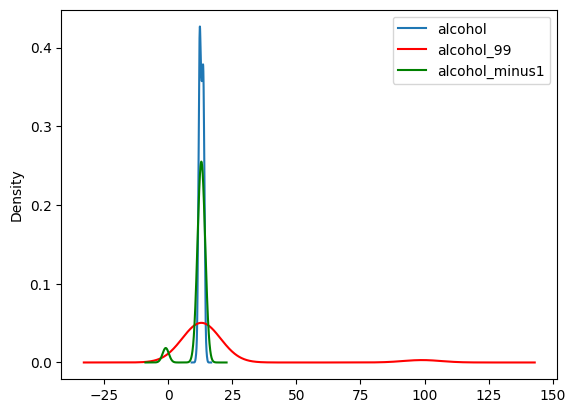

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['alcohol'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['alcohol_99'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['alcohol_minus1'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')